# Instalar librería darts si es necesario

In [2]:
#%pip install darts

# Importar Librerias

In [3]:
import pandas as pd
from darts import TimeSeries
import matplotlib.pyplot as plt
from scipy.stats import boxcox
import numpy as np
from darts.datasets import AirPassengersDataset

# Cargar data de libreria darts

In [4]:
dataset = AirPassengersDataset()#Es un DF que está guardado en Python
series = dataset.load() #acá cargamos el DF y le llamamos series, haciendo ref que será un serie temporal

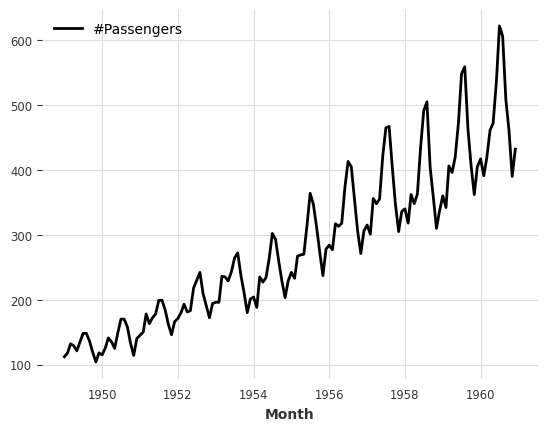

In [5]:
series.plot()
plt.show()

# Transformación de Serie Temporal

## Logaritmo

In [ ]:
#código deprecado del profe
#log_data = np.log(series.pd_series()) 
#log_series = TimeSeries.from_series(log_data)

#log_series.plot()#Lo gráfica
#plt.show()

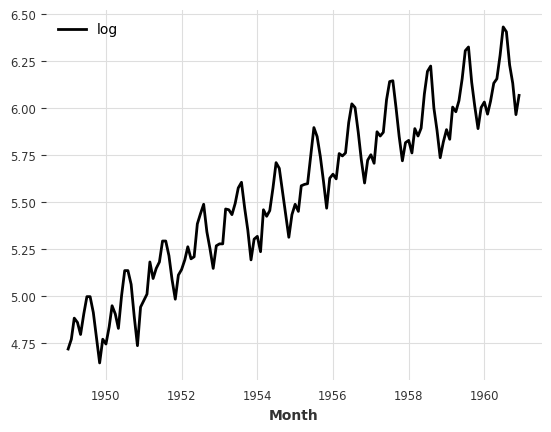

In [6]:
#Mi versión
#Extraer fechas y valores usando Numpy
values = series.values()#Numpy array
time_index = series.time_index#índice temporal

# Crear DataFrame de pandas, para respetar el proceso del profe. 
log_data = pd.DataFrame(values, index=time_index, columns=["value"])#se crea un DF llamado como en el código deprecado

# Aplicar logaritmo
log_data["log"] = np.log(log_data["value"])
log_series = TimeSeries.from_dataframe(log_data, value_cols="log")
log_series.plot()#Lo gráfica
plt.show()

* #### Tendencia:
Incluso con escala logarítmica, la serie sigue mostrando una tendencia creciente (valores suben con el tiempo), lo que indica que el crecimiento no es puramente exponencial. El log ayudó a "suavizar" ese crecimiento, pero aún queda pendiente quitar esa tendencia.

* #### Estacionalidad: 
Se nota un patrón repetitivo (sube y baja en los mismos meses) señalando un componente estacional clara. Acá el log no eliminó la estacionalidad, solo cambió la escala de amplitud de los ciclos.

* #### Efecto del logaritmo: 
En la serie original, los picos eran cada vez más grandes (tenía amplitud creciente). Y con el logaritmo, esa amplitud se “controla” -ya no creció tanto con el tiempo- convirtiendo una variabilidad multiplicativa (proporcional al nivel de la serie) en variabilidad aditiva (más estable en magnitud).

## Diferenciación

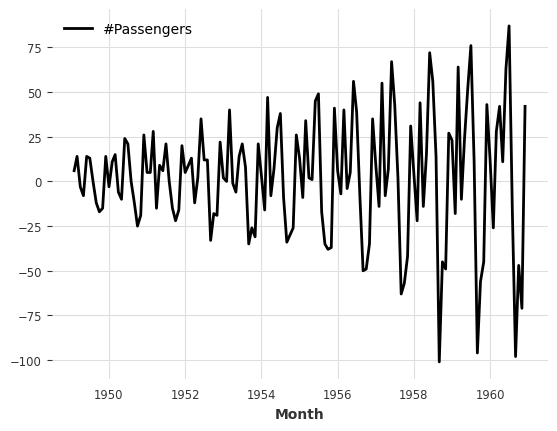

In [7]:
# Diferenciación es útil para eliminar tendencia.
diff_series = series.diff()
diff_series.plot()
plt.show()

# Box-Cox

In [ ]:
#Mi versión
#Extraer fechas y valores usando Numpy
values = series.values()#Numpy array
time_index = series.time_index#índice temporal

# Crear DataFrame de pandas, para respetar el proceso del profe. 
values = pd.DataFrame(values, index=time_index, columns=["value"])#se crea un DF llamado como en el código deprecado

boxcox_values, lambda_value = boxcox(values["value"].to_numpy())#.boxcox exige un arreglo 1D. De ahí que involucre la columna
print(f'Lambda: {lambda_value}')#Valor de parámetro

Lambda: 0.14802261727063243


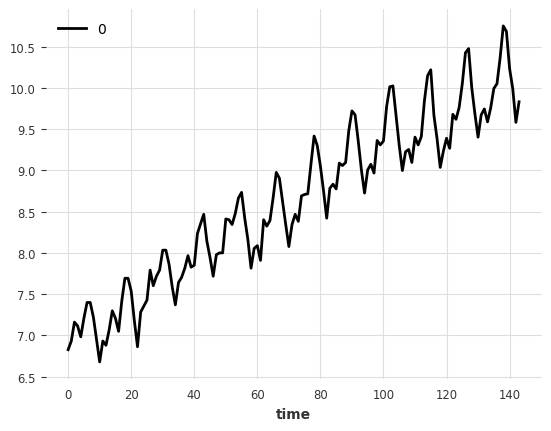

In [ ]:
#Acá se crea una TimeSeries nueva a partir de un array (boxcox_values).
boxcox_series = TimeSeries.from_values(boxcox_values)#Así, obteniendo solo los valores. Así se pierde el índice temporal
boxcox_series.plot()
plt.show()

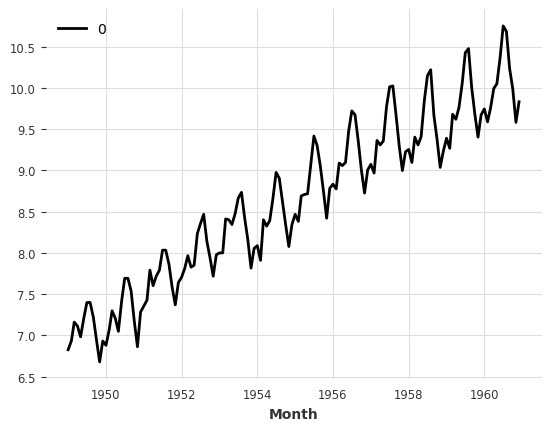

In [ ]:
# 1) conserva las fechas originales
time_index = series.time_index  # Para fijar el index de fechas
boxcox_series = TimeSeries.from_times_and_values(time_index, boxcox_values)#Así, obteniendo los valores y las fechas del index
boxcox_series.plot()
plt.show()

# Tarea propuesta

Lambda: 0.14802261727063243


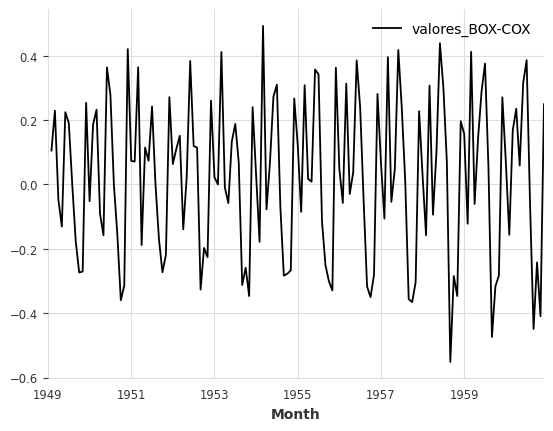

In [43]:
#PRIMERO, ESTABILIZAR VARIANZA
values_T = series.values()#Numpy array
#Extraer fechas y valores usando Numpy
time_index_T = series.time_index#índice temporal
# Crear DataFrame de pandas, para respetar el proceso del profe. 
values_T = pd.DataFrame(values_T, index=time_index_T, columns=['valores'])#se crea un DF llamado como en el código deprecado

boxcox_values_T, lambda_value_T = boxcox(values_T['valores'].to_numpy())#.boxcox exige un arreglo 1D. De ahí que involucre la columna
print(f'Lambda: {lambda_value_T}')#Valor de parámetro, sigue siendo 0.148 

boxcox_values_T = pd.DataFrame(boxcox_values_T, index=time_index_T, columns=['valores_BOX-COX'])

#SEGUNDO, APLICAMOS PRIMERAS DIFERENCIAS PARA DESAPARECER TENDENCIA
diff_series_T = boxcox_values_T.diff()
diff_series_T.plot()
plt.show()